# Travel Assistant AI System Evaluation with GAICo

This notebook demonstrates how to evaluate composite AI systems using GAICo. We compare three distinct "pipelines" of an AI Travel Assistant, each comprising an orchestrator LLM and specialist image and audio generation models.

The evaluation is split into two crucial parts:

1.  **Plan Coherence:** How well does the orchestrator LLM (e.g., GPT-4, Llama 4, Gemini 2.5 Pro) generate the core textual itinerary, planning sequence, and budget, compared to a single, high-quality human-curated reference?

2.  **Modality Generation Quality:** Given the specific prompts/scripts generated by _each pipeline's own orchestrator_, how well do the specialist image and audio models (e.g., DALL-E 3, Stable Diffusion XL, Google Imagen; OpenAI TTS, Kokoro TTS, Google 2.5 Flash) perform in generating their respective outputs? This evaluates the downstream models' ability to follow instructions.

This approach allows us to pinpoint whether issues lie in the high-level planning or the execution of specific modalities.


In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from gaico import Experiment
from gaico.visualize import plot_radar_comparison, plot_metric_comparison

### Configuration

Define paths and pipeline names for data loading and saving.


In [2]:
# Configuration
PIPELINES = ["pipeline_A", "pipeline_B", "pipeline_C"]
DAYS = [1, 2, 3]  # Number of days in the itinerary
ROOT_DIR = (
    Path(os.getcwd()) / "data" / "case_study"
)  # Assumes 'data/case_study' is relative to script
OUTPUTS_DIR = ROOT_DIR / "outputs"
REFERENCE_DIR = ROOT_DIR / "reference"

# Create a directory to save the figures
FIGURES_DIR = ROOT_DIR / "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

## PART 1: Evaluating Plan Coherence (Orchestrator Quality)

In this section, we assess how well each pipeline's orchestrator LLM generated the core itinerary text, planning sequences, and budget. All pipelines are compared against a _single, universal human-curated reference plan_. This helps determine which orchestrator model is most effective at generating the structured core of the travel plan.


In [3]:
print("=" * 57)
print("Part 1: Evaluating Plan Coherence (Orchestrator Quality)")
print("=" * 57)

# Load the single, high-quality baseline reference plan
with open(REFERENCE_DIR / "reference.json") as f:
    reference_data = json.load(f)

Part 1: Evaluating Plan Coherence (Orchestrator Quality)


In [4]:
# Prepare lists of reference data across all days
ref_texts = [day["day_plan_text"] for day in reference_data["trip_plan"]]
ref_plans = [day["day_plan_sequence"] for day in reference_data["trip_plan"]]
ref_budgets_str = [
    f"Day{day['day']}:{day['day_budget_euros']}" for day in reference_data["trip_plan"]
]

In [5]:
# Prepare a dictionary of generated data for all pipelines (for batch processing)
gen_data_all_pipelines = {}
for pipeline_name in PIPELINES:
    try:
        with open(OUTPUTS_DIR / pipeline_name / "output.json") as f:
            gen_data_all_pipelines[pipeline_name] = json.load(f)
    except FileNotFoundError:
        print(f"ERROR: output.json not found for {pipeline_name}. Skipping.")
    except Exception as e:
        print(f"An unexpected error occurred for {pipeline_name}: {e}. Skipping.")

In [6]:
# Structure data for Experiment class
text_responses = {
    p_name: [day["day_plan_text"] for day in p_data["trip_plan"]]
    for p_name, p_data in gen_data_all_pipelines.items()
}
plan_responses = {
    p_name: [day["day_plan_sequence"] for day in p_data["trip_plan"]]
    for p_name, p_data in gen_data_all_pipelines.items()
}
budget_responses = {
    p_name: [f"Day{day['day']}:{day['day_budget_euros']}" for day in p_data["trip_plan"]]
    for p_name, p_data in gen_data_all_pipelines.items()
}

In [7]:
# Use Experiment for batch evaluation
# 1. Evaluate textual descriptions
exp_text = Experiment(llm_responses=text_responses, reference_answer=ref_texts)
df_text_scores = exp_text.to_dataframe(metrics=["ROUGE", "BERTScore"])

# 2. Evaluate planning sequences
exp_plan = Experiment(llm_responses=plan_responses, reference_answer=ref_plans)
df_plan_scores = exp_plan.to_dataframe(metrics=["PlanningLCS", "PlanningJaccard"])

# 3. Evaluate budget time-series
exp_budget = Experiment(llm_responses=budget_responses, reference_answer=ref_budgets_str)
df_budget_scores = exp_budget.to_dataframe(metrics=["TimeSeriesDTW"])

# Concatenate all results into a single long-format DataFrame
df_plan_coherence_long = pd.concat(
    [df_text_scores, df_plan_scores, df_budget_scores], ignore_index=True
)

# Filter df_plan_coherence_long to include only the desired specific sub-metrics
desired_plan_metrics = [
    "ROUGE_rougeL",
    "BERTScore_f1",
    "PlanningLCS",
    "PlanningJaccard",
    "TimeSeriesDTW",
]
df_plan_coherence_long = df_plan_coherence_long[
    df_plan_coherence_long["metric_name"].isin(desired_plan_metrics)
].copy()  # .copy() to avoid SettingWithCopyWarning

In [8]:
# Create a wide-format summary DataFrame for display and CSV (by averaging scores)
df_plan_coherence = (
    df_plan_coherence_long.groupby(["model_name", "metric_name"])["score"]
    .mean()
    .unstack()
    .rename_axis(None, axis=1)
    .rename_axis("pipeline")
)

# Display and save the final Plan Coherence DataFrame
print("\nPlan Coherence Results (Averaged over 3 days)")
print(df_plan_coherence.round(3))
df_plan_coherence.to_csv(ROOT_DIR / "results_plan_coherence.csv")


Plan Coherence Results (Averaged over 3 days)
            BERTScore_f1  PlanningJaccard  PlanningLCS  ROUGE_rougeL  \
pipeline                                                               
pipeline_A         1.000            1.000        1.000         1.000   
pipeline_B         0.599            0.083        0.095         0.190   
pipeline_C         0.613            0.117        0.137         0.222   

            TimeSeriesDTW  
pipeline                   
pipeline_A          1.000  
pipeline_B          0.122  
pipeline_C          0.367  


## PART 2: Evaluating Modality Generation (Specialist Model Quality)

This section evaluates the quality of outputs from the specialist image and audio generation models within each pipeline. Crucially, the _reference_ for each pipeline's image and audio output is derived from that pipeline's _own orchestrator-generated prompts_.

This setup ensures we evaluate the specialist model's ability to fulfill its specific prompt, isolating its performance from the orchestrator's planning.


In [9]:
print("\n" + "=" * 66)
print("Part 2: Evaluating Modality Generation (Specialist Model Quality)")
print("=" * 66)

modality_dfs_long = []


Part 2: Evaluating Modality Generation (Specialist Model Quality)


In [10]:
for pipeline_name in PIPELINES:
    print(f"Evaluating Modalities for: {pipeline_name}")

    # Find generated and reference files for this pipeline
    gen_image_files = sorted(
        [f for ext in ("*.png", "*.jpeg") for f in (OUTPUTS_DIR / pipeline_name).glob(ext)]
    )
    ref_image_files = sorted(
        [f for ext in ("*.png", "*.jpeg") for f in (REFERENCE_DIR / pipeline_name).glob(ext)]
    )
    gen_audio_files = sorted(
        [str(f) for ext in ("*.mp3", "*.wav") for f in (OUTPUTS_DIR / pipeline_name).glob(ext)]
    )
    ref_audio_files = sorted(
        [str(f) for ext in ("*.mp3", "*.wav") for f in (REFERENCE_DIR / pipeline_name).glob(ext)]
    )

    if not (gen_image_files and ref_image_files and gen_audio_files and ref_audio_files):
        print(f"Warning: Missing files for {pipeline_name}. Skipping modality evaluation.")
        continue

    # Use Experiment for Image Evaluation
    gen_images = [Image.open(f) for f in gen_image_files]
    ref_images = [Image.open(f) for f in ref_image_files]
    exp_img = Experiment(llm_responses={pipeline_name: gen_images}, reference_answer=ref_images)
    df_img = exp_img.to_dataframe(metrics=["ImageSSIM", "ImageAverageHash", "ImageHistogramMatch"])
    modality_dfs_long.append(df_img)

    # --- Use Experiment for Audio Evaluation ---
    exp_aud = Experiment(
        llm_responses={pipeline_name: gen_audio_files}, reference_answer=ref_audio_files
    )
    df_aud = exp_aud.to_dataframe(metrics=["AudioSNR", "AudioSpectrogramDistance"])
    modality_dfs_long.append(df_aud)

Evaluating Modalities for: pipeline_A
Evaluating Modalities for: pipeline_B
Evaluating Modalities for: pipeline_C


In [11]:
# Concatenate all pipeline results
df_modality_quality_long = pd.concat(modality_dfs_long, ignore_index=True)

# Filter df_modality_quality_long to include only the desired specific sub-metrics
desired_modality_metrics = [
    "ImageSSIM",
    "ImageAverageHash",
    "ImageHistogramMatch",
    "AudioSNR",
    "AudioSpectrogramDistance",
]
df_modality_quality_long = df_modality_quality_long[
    df_modality_quality_long["metric_name"].isin(desired_modality_metrics)
].copy()

# Create a wide-format summary DataFrame for display and CSV
df_modality_quality = (
    df_modality_quality_long.groupby(["model_name", "metric_name"])["score"]
    .mean()
    .unstack()
    .rename_axis(None, axis=1)
    .rename_axis("pipeline")
)

In [12]:
# Display and save the final Modality Quality DataFrame
print("\nModality Generation Quality Results (Averaged over 3 days)")
print(df_modality_quality.round(3))
df_modality_quality.to_csv(ROOT_DIR / "results_modality_quality.csv")

print("\nEvaluation complete. Results saved to CSV files.")


Modality Generation Quality Results (Averaged over 3 days)
            AudioSNR  AudioSpectrogramDistance  ImageAverageHash  \
pipeline                                                           
pipeline_A     1.000                     1.000             1.000   
pipeline_B     0.249                     0.261             0.646   
pipeline_C     0.247                     0.260             0.766   

            ImageHistogramMatch  ImageSSIM  
pipeline                                    
pipeline_A                1.000      1.000  
pipeline_B                0.642      0.276  
pipeline_C                0.528      0.347  

Evaluation complete. Results saved to CSV files.


## Visualization

This section generates professional-quality plots using GAICo's visualization module and Matplotlib/Seaborn.

We will create:

- Radar plots for a holistic overview of pipeline performance across multiple metrics.
- Bar plots for a detailed, metric-by-metric comparison.


In [13]:
# Configuration for Professional Plots
# Use a professional color palette
PALETTE = "viridis"
# Set a consistent style for all plots
sns.set_theme(style="whitegrid", palette=PALETTE)
# High-resolution output for publications
DPI = 300

In [14]:
def create_plan_coherence_visuals(df_long):
    """Generates and saves radar and bar plots for plan coherence results."""
    print("\nGenerating visuals for Plan Coherence")

    # The input df_long is already in the correct format for GAICo's plotters.

    # 1. Create the main Radar Plot for a holistic overview
    print("Creating Plan Coherence Radar Plot...")
    plt.figure(figsize=(8, 8))
    radar_ax = plt.subplot(111, polar=True)
    plot_radar_comparison(
        df_long, axis=radar_ax, title="Plan Coherence: Overall Pipeline Performance"
    )
    # Improve legend placement
    radar_ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "plan_coherence_radar.png"), dpi=DPI)
    plt.show()

    # 2. Create detailed Bar Plots for each metric
    print("Creating Plan Coherence Bar Plots...")
    metrics = df_long["metric_name"].unique()
    # Create a grid of subplots (e.g., 2 rows, 3 columns)
    # The current 5 metrics (ROUGE_rougeL, BERTScore_f1, PlanningLCS, PlanningJaccard, TimeSeriesDTW)
    # fit well into a 2x3 grid with one empty slot.
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 10),
        sharey=True,  # All plots will have the same y-axis scale
    )
    axes = axes.flatten()  # Flatten for easy iteration

    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_metric_comparison(
            df_long, metric_name=metric, axis=ax, title=f"Comparison for: {metric}"
        )
        ax.set_xlabel("")  # Remove redundant x-axis labels
        ax.tick_params(axis="x", rotation=15)  # Rotate labels slightly

        # Add score labels on top of each bar for clarity
        for bar in ax.patches:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{bar.get_height():.3f}",
                ha="center",
                va="bottom",
            )

    # Hide any unused subplots
    for i in range(len(metrics), len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle("Plan Coherence: Detailed Metric-by-Metric Breakdown", fontsize=20)
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))  # Adjust for suptitle
    plt.savefig(os.path.join(FIGURES_DIR, "plan_coherence_bars.png"), dpi=DPI)
    plt.show()

In [15]:
def create_modality_quality_visuals(df_long):
    """Generates and saves radar and bar plots for modality quality results."""
    print("\nGenerating visuals for Modality Generation Quality")

    # The input df_long is already in the correct format for GAICo's plotters.

    # 1. Create Radar Plot
    print("Creating Modality Quality Radar Plot...")
    plt.figure(figsize=(8, 8))
    radar_ax = plt.subplot(111, polar=True)
    plot_radar_comparison(
        df_long, axis=radar_ax, title="Modality Generation Quality: Specialist Model Performance"
    )
    radar_ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "modality_quality_radar.png"), dpi=DPI)
    plt.show()

    # 2. Create Bar Plots
    print("Creating Modality Quality Bar Plots...")
    metrics = df_long["metric_name"].unique()
    # There are 5 modality metrics (3 image, 2 audio), so a 2x3 grid is appropriate
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharey=True)
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_metric_comparison(
            df_long, metric_name=metric, axis=ax, title=f"Comparison for: {metric}"
        )
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=15)

        # Add score labels
        for bar in ax.patches:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{bar.get_height():.3f}",
                ha="center",
                va="bottom",
            )

    # Hide any unused subplots if the number of metrics is not a multiple of 3
    for i in range(len(metrics), len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle("Modality Generation Quality: Detailed Metric-by-Metric Breakdown", fontsize=20)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.savefig(os.path.join(FIGURES_DIR, "modality_quality_bars.png"), dpi=DPI)
    plt.show()

## Run Analysis and Generate Visualizations

This final section uses the in-memory DataFrames generated above and calls the visualization functions to create the plots.



Generating visuals for Plan Coherence
Creating Plan Coherence Radar Plot...


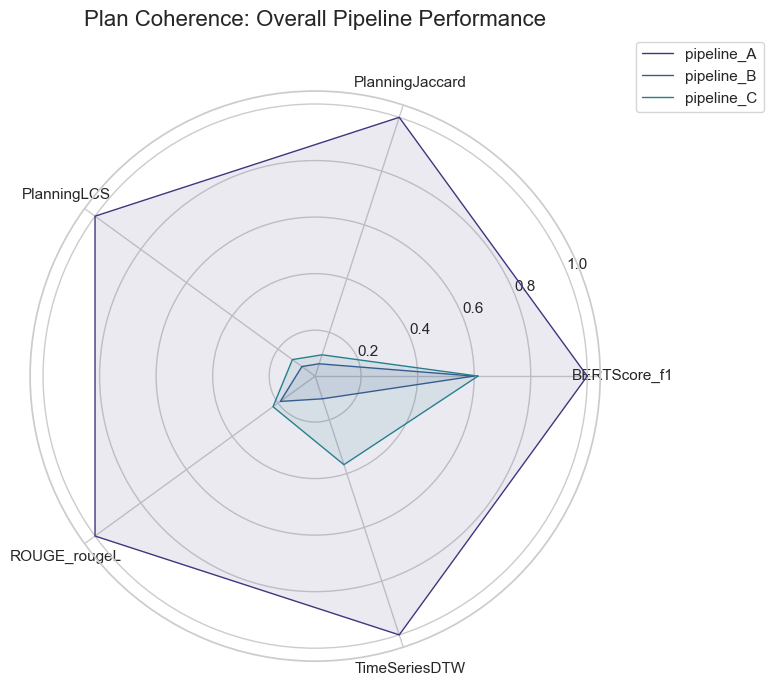

Creating Plan Coherence Bar Plots...


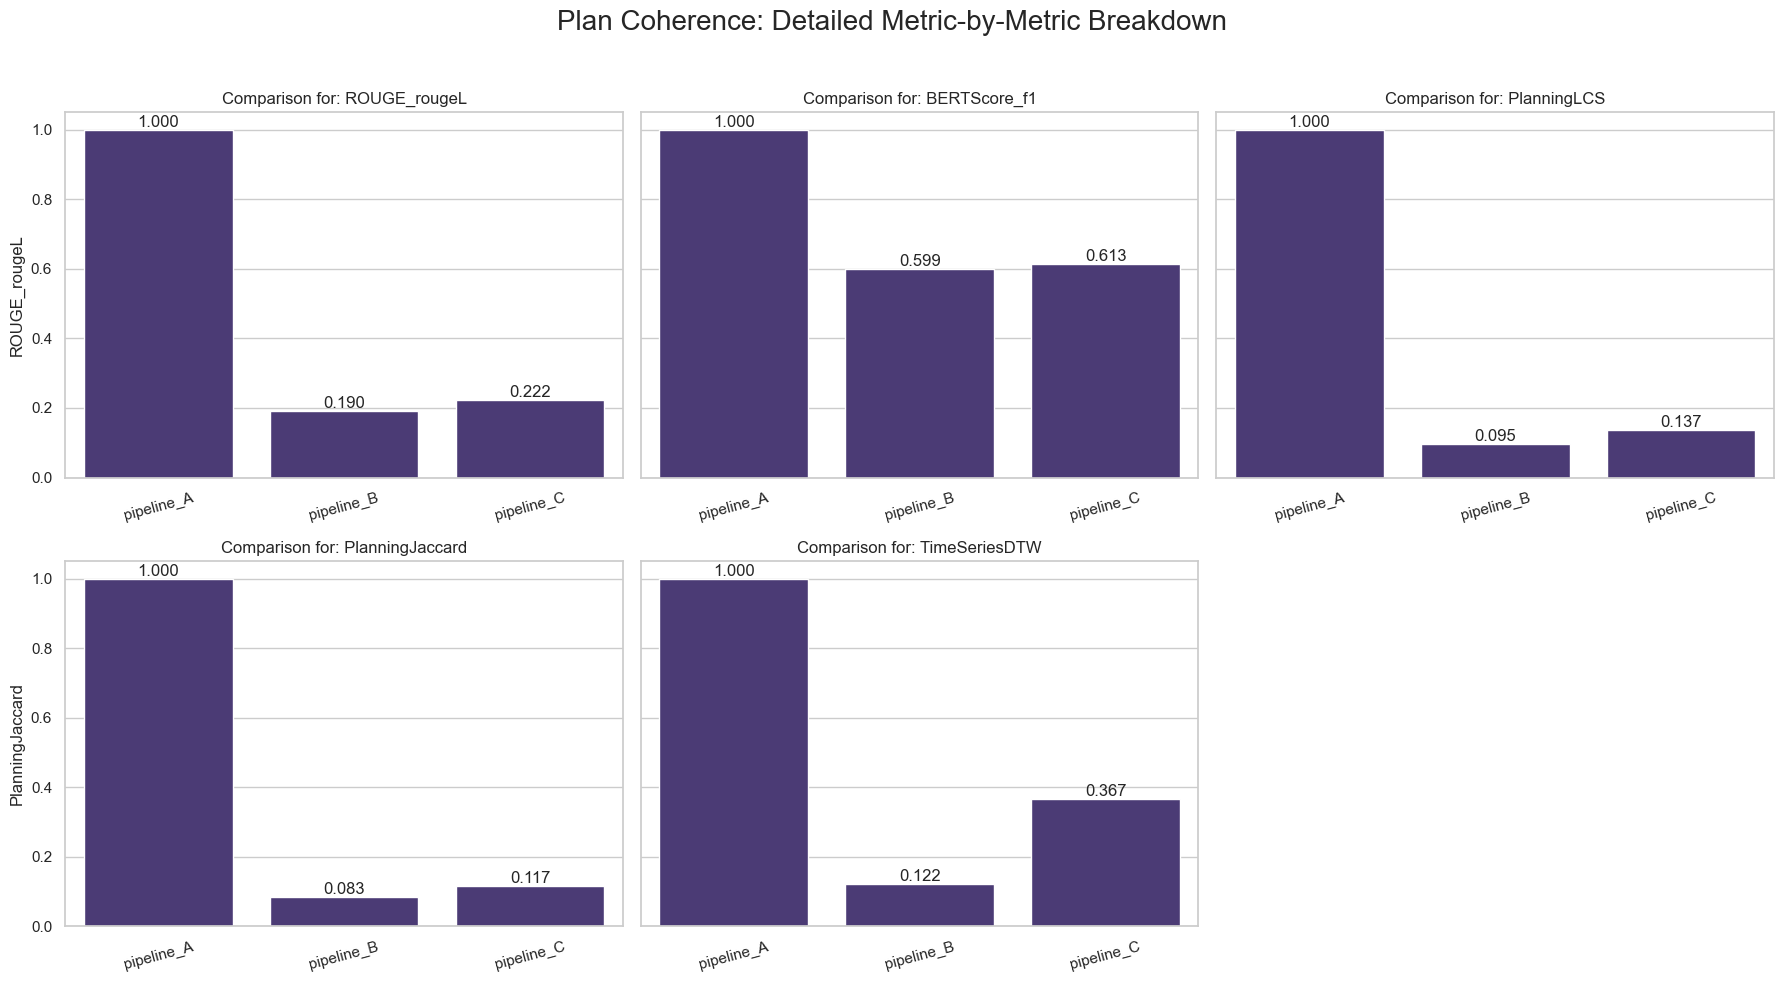


Generating visuals for Modality Generation Quality
Creating Modality Quality Radar Plot...


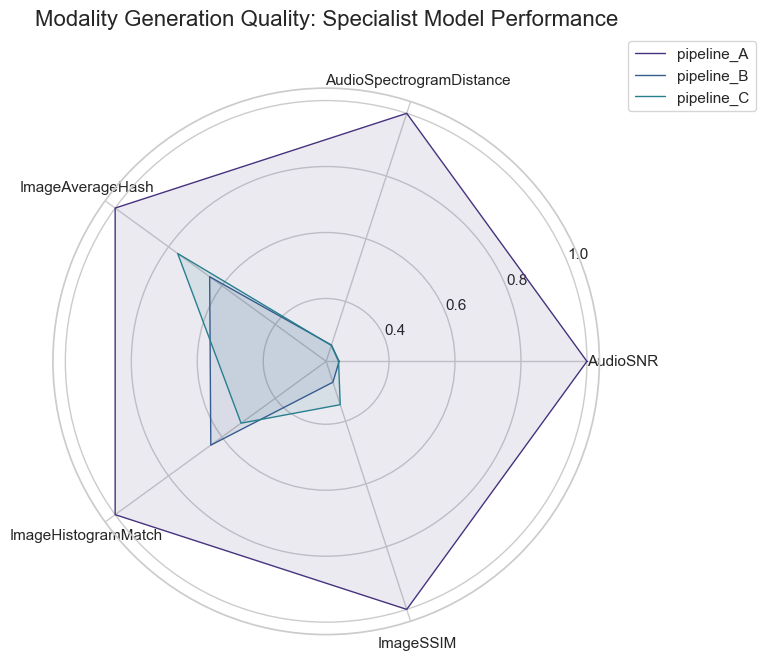

Creating Modality Quality Bar Plots...


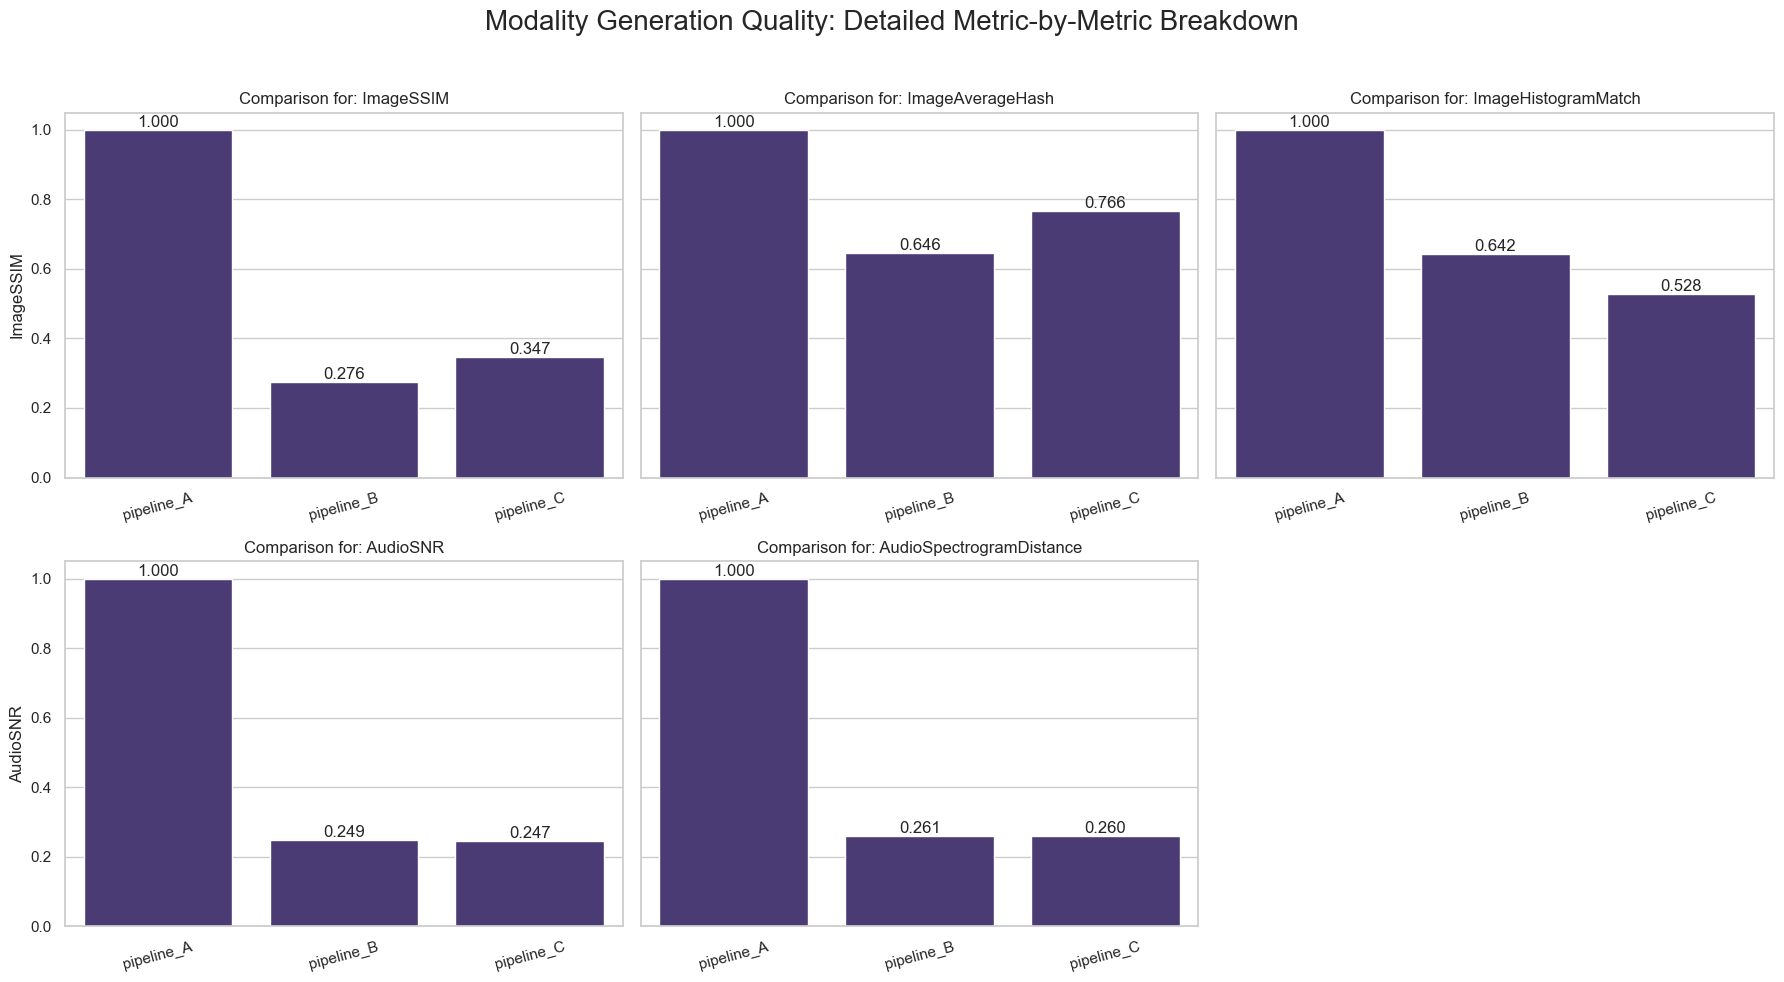


All figures have been saved to the '/Users/nitingupta/usc/ai4s/libraries/GenAIResultsComparator/examples/data/case_study/figures' directory.


In [16]:
# Generate Visualizations using the long-format DataFrames created in Parts 1 & 2
create_plan_coherence_visuals(df_plan_coherence_long)
create_modality_quality_visuals(df_modality_quality_long)

print(f"\nAll figures have been saved to the '{FIGURES_DIR}' directory.")

## Discussion

GAICo's unified framework enabled us to efficiently generate quantitative results for both evaluation tasks, which are summarized in tables.

Using GAICo's visualization module, we generated radar plots for a holistic overview and detailed bar charts for granular analysis.

### Orchestrator Performance

Pipeline A’s (GPT-5) orchestrator consistently achieved perfect scores (1.000) across all plan coherence metrics, as its outputs defined the human-curated reference. Pipeline B (Llama 4) and Pipeline C (Gemini 2.5 Pro) showed significantly lower performance, deviating substantially from the baseline plan. Pipeline C outperformed Pipeline B, especially in `TimeSeriesDTW (0.367 vs. 0.122), suggesting better budget forecast approximation.

### Modality Generation Quality

The modality generation quality results show the execution fidelity of specialist models against high-quality references. Pipeline A’s specialist models (DALL-E 3, OpenAI TTS) achieved perfect scores as their outputs defined the modality-specific references. Pipeline C (Imagen) generally outperformed Pipeline B (Stable Diffusion XL) in `Image SSIM` (0.347 vs. 0.267) and `Image AverageHash` (0.766 vs. 0.646), indicating stronger structural and perceptual similarity. However, Pipeline B showed a slightly higher `Image HistogramMatch` score (0.642 vs. 0.528), suggesting its color distribution was closer to the baseline. This highlights the value of multi-metric evaluation.

Audio metrics showed lower `Audio SNR` (0.249 and 0.247, respectively) and `Audio SpectogramDist` (0.261 and 0.260, respectively) for Pipeline B (Kokoro TTS) and Pipeline C (Google 2.5 Flash) compared to Pipeline A (1.000). This indicates that while their orchestrators provided valid scripts, their specialist audio models are not yet capable of matching the fidelity of the baseline OpenAI TTS.
